# 03 · Política de inventario y alertas

**Objetivo:** convertir el pronóstico en decisiones: cuánto stock de seguridad tener, cuándo pedir, cuánto pedir y qué alertas atender (quiebre, sobrestock, vencimiento).

Fecha de corte (el "hoy" de la simulación): **31-dic-2025**.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Permite importar el paquete del proyecto (src/healthsupply) desde el notebook.
sys.path.insert(0, str(Path.cwd().parent / "src"))
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

from healthsupply.data_loading import cargar_todo
from healthsupply.config import DATA_PROCESSED
from healthsupply import figures  # aplica el estilo de gráficos del proyecto
import numpy as np
from statistics import NormalDist
from healthsupply import inventory_policy as ip, alerts
from IPython.display import Image

t = cargar_todo()
futuro = pd.read_csv(DATA_PROCESSED / "pronostico_futuro.csv", parse_dates=["fecha"])
bt = pd.read_csv(DATA_PROCESSED / "pronostico_backtest.csv", parse_dates=["fecha"])
mejor = futuro["modelo"].iloc[0]
bt_mejor = bt[bt["modelo"] == mejor]
print("Modelo usado:", mejor)

Modelo usado: RandomForest


## 1. Clasificación ABC

No todos los productos merecen la misma protección. La clasificación ABC (Pareto) ordena los productos por **valor consumido** en los últimos 12 meses:
- **A**: suman el primer 80 % del valor → nivel de servicio 98 %
- **B**: hasta el 95 % → 95 %
- **C**: el resto → 90 %

In [2]:
abc = ip.clasificacion_abc(t["fact_demanda"], t["dim_producto"])
abc.assign(valor_millones=(abc["valor_consumo_12m"] / 1e6).round(1), pct_acumulado=(abc["pct_acumulado"] * 100).round(1))

,producto_id,unidades_12m,valor_consumo_12m,pct_acumulado,clase_abc,valor_millones
11,MED-012,33401,116903500,15.1,A,116.9
8,MED-009,74551,89461200,26.7,A,89.5
13,MED-014,18630,78246000,36.8,A,78.2
12,MED-013,29836,62655600,44.8,A,62.7
14,MED-015,22322,58037200,52.3,A,58.0
7,MED-008,28042,51877700,59.0,A,51.9
4,MED-005,16813,47076400,65.1,A,47.1
5,MED-006,14853,43073700,70.7,A,43.1
9,MED-010,40906,38860700,75.7,A,38.9
6,MED-007,59637,38764050,80.7,A,38.8


> En este dataset los costos son parecidos entre productos, así que el valor se reparte y 10 de 15 quedan en A. En un hospital real (con medicamentos de alto costo) la curva suele ser mucho más concentrada.

## 2. Stock de seguridad paso a paso (ejemplo MED-001 en LOC-001)

$$SS = z \times \sqrt{LT \cdot \sigma_e^2 + \bar d^2 \cdot \sigma_{LT}^2}$$

- $\bar d$: demanda diaria pronosticada
- $\sigma_e$: desviación del **error** del pronóstico (lo que el modelo no logra predecir)
- $LT, \sigma_{LT}$: promedio y desviación del lead time real
- $z$: factor de la normal estándar para el nivel de servicio

In [3]:
ids = {"producto_id": "MED-001", "ubicacion_id": "LOC-001"}
sel = lambda df: df[(df["producto_id"] == ids["producto_id"]) & (df["ubicacion_id"] == ids["ubicacion_id"])]

d = sel(futuro)["yhat"].mean()
errores = sel(bt_mejor)["y"] - sel(bt_mejor)["yhat"]
sigma_e = errores.std()
lt_stats = ip.estadisticas_lead_time(t["fact_compras"]).set_index("producto_id").loc["MED-001"]
LT, sigma_lt = lt_stats["lead_time_prom"], lt_stats["lead_time_desv"]
nivel = 0.95   # MED-001 es clase B
z = NormalDist().inv_cdf(nivel)

var_demanda = LT * sigma_e**2
var_lead_time = d**2 * sigma_lt**2
SS = np.ceil(z * np.sqrt(var_demanda + var_lead_time))
ROP = np.ceil(d * LT + SS)
S = np.ceil(d * (LT + 28) + SS)

print(f"d = {d:.2f} u/día | sigma_e = {sigma_e:.2f} | LT = {LT:.2f} días | sigma_LT = {sigma_lt:.2f} | z = {z:.3f}")
print(f"Varianza por demanda:   {var_demanda:,.0f}  ({var_demanda / (var_demanda + var_lead_time):.0%})")
print(f"Varianza por lead time: {var_lead_time:,.0f}  ({var_lead_time / (var_demanda + var_lead_time):.0%})")
print(f"Stock de seguridad = {SS:.0f} u | Punto de reorden = {ROP:.0f} u | Stock máximo = {S:.0f} u")

d = 68.92 u/día | sigma_e = 9.34 | LT = 11.85 días | sigma_LT = 1.50 | z = 1.645
Varianza por demanda:   1,034  (9%)
Varianza por lead time: 10,635  (91%)
Stock de seguridad = 178 u | Punto de reorden = 995 u | Stock máximo = 2925 u


**Interpretación:** ~91 % de la incertidumbre viene del **lead time** y solo ~9 % de la demanda. Gracias al buen pronóstico, el error de demanda es pequeño; lo que obliga a guardar colchón es la variabilidad del proveedor. Negociar entregas más puntuales reduciría el stock de seguridad más que seguir mejorando el modelo.

### ¿Cuánto stock de seguridad ahorra el ML frente al modelo base?
Recalculamos la política completa usando los errores del mejor modelo base (mismo d, mismo lead time):

In [4]:
base = bt[bt["modelo"] == "promedio_dia_semana_8s"]
args = (t["fact_inventario"], t["fact_compras"], t["fact_demanda"], t["dim_producto"])
pol_ml = ip.calcular_politica(futuro, bt_mejor, *args)
pol_base = ip.calcular_politica(futuro, base, *args)
comparacion = pd.DataFrame({
    "sigma_error_prom": [pol_ml["sigma_error_diario"].mean(), pol_base["sigma_error_diario"].mean()],
    "stock_seguridad_total_u": [pol_ml["stock_seguridad"].sum(), pol_base["stock_seguridad"].sum()],
    "valor_stock_seguridad_cop": [(pol_ml["stock_seguridad"] * pol_ml["costo_unitario"]).sum(),
                                  (pol_base["stock_seguridad"] * pol_base["costo_unitario"]).sum()]},
    index=["ML (" + mejor + ")", "Base (promedio_dia_semana_8s)"])
comparacion.round(1)

,sigma_error_prom,stock_seguridad_total_u,valor_stock_seguridad_cop
ML (RandomForest),3.2,5714.0,7948430.0
Base (promedio_dia_semana_8s),4.2,5873.0,8159830.0


El σ del error baja ~20-25 % con el ML, pero el stock de seguridad total baja poco porque **domina la variabilidad del lead time**. Lección importante: el beneficio de un mejor pronóstico sobre el stock de seguridad depende de qué fuente de incertidumbre domina. Aquí el mayor valor del ML está en estimar bien la **demanda esperada** (sin sesgo), que define el punto de reorden y el stock máximo, y en anticipar cambios de nivel como la caída de diciembre.

## 3. Política para las 75 combinaciones producto x sede

In [5]:
politica = pd.read_csv(DATA_PROCESSED / "politica_inventario.csv")
cols = ["producto_id", "ubicacion_id", "clase_abc", "demanda_diaria_pronostico", "stock_seguridad", "punto_reorden",
        "stock_maximo", "inventario_disponible", "inventario_en_transito", "dias_cobertura", "cantidad_sugerida",
        "estado_inventario"]
politica[cols].round(1).head(10)

,producto_id,ubicacion_id,clase_abc,demanda_diaria_pronostico,stock_seguridad,punto_reorden,stock_maximo,inventario_disponible,inventario_en_transito,dias_cobertura,cantidad_sugerida,estado_inventario
0,MED-001,LOC-001,B,68.9,178.0,995.0,2925.0,10091,260,146.4,0,SOBRESTOCK
1,MED-001,LOC-002,B,53.4,137.0,770.0,2266.0,6791,218,127.2,0,SOBRESTOCK
2,MED-001,LOC-003,B,40.9,105.0,590.0,1734.0,5492,174,134.4,0,SOBRESTOCK
3,MED-001,LOC-004,B,31.3,82.0,454.0,1331.0,4290,141,136.9,0,SOBRESTOCK
4,MED-001,LOC-005,B,36.6,95.0,530.0,1555.0,4957,140,135.3,0,SOBRESTOCK
5,MED-002,LOC-001,B,59.9,148.0,876.0,2554.0,8568,197,143.0,0,SOBRESTOCK
6,MED-002,LOC-002,B,46.2,113.0,675.0,1968.0,5298,192,114.7,0,SOBRESTOCK
7,MED-002,LOC-003,B,35.6,87.0,520.0,1518.0,4430,139,124.3,0,SOBRESTOCK
8,MED-002,LOC-004,B,26.7,65.0,390.0,1138.0,3848,115,144.1,0,SOBRESTOCK
9,MED-002,LOC-005,B,30.9,76.0,452.0,1317.0,4394,119,142.1,0,SOBRESTOCK


In [6]:
politica["estado_inventario"].value_counts()

estado_inventario
SOBRESTOCK    75
Name: count, dtype: int64

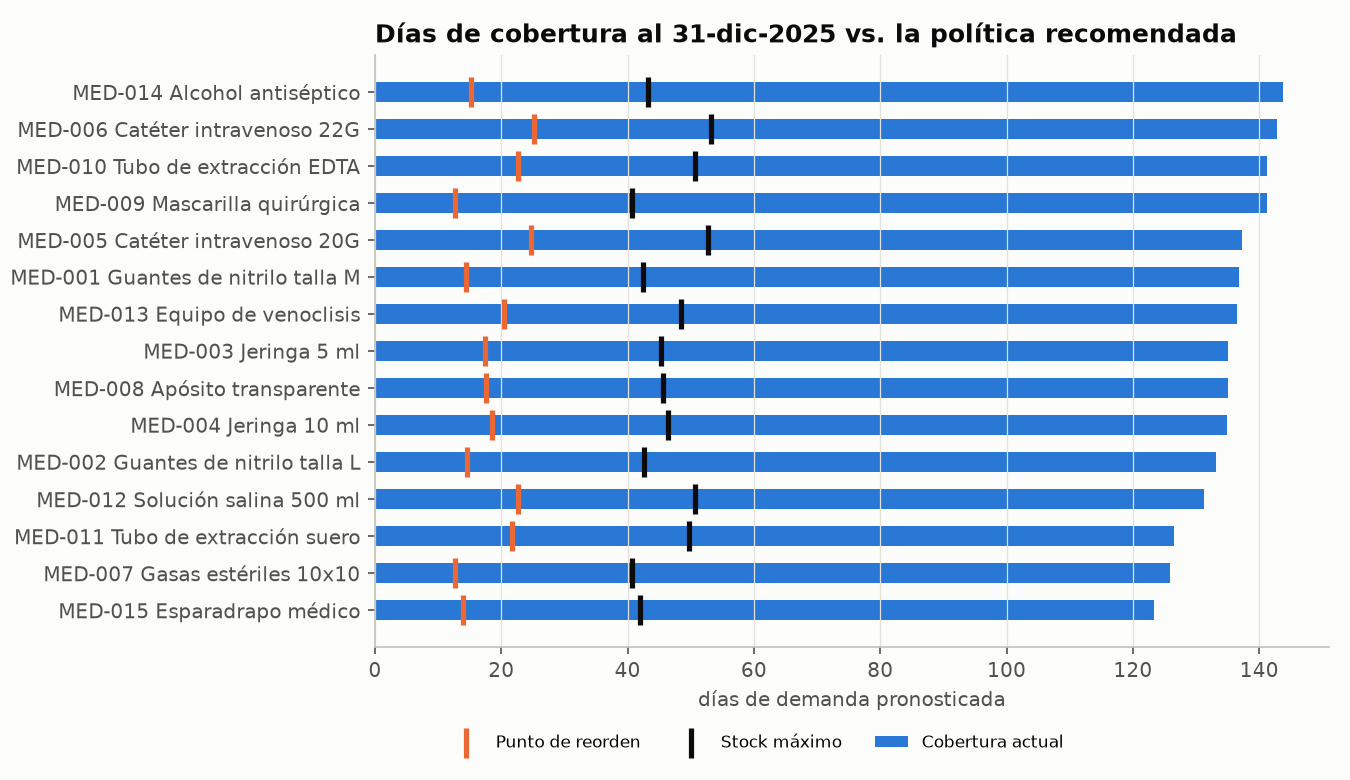

In [7]:
Image(figures.FIGURES / "05_cobertura_vs_politica.png")

In [8]:
exceso = politica["valor_exceso"].sum()
total = (politica["inventario_disponible"] * politica["costo_unitario"]).sum()
print(f"Valor del inventario disponible: ${total / 1e6:,.1f} millones COP")
print(f"Valor por encima del stock máximo: ${exceso / 1e6:,.1f} millones COP ({exceso / total:.0%})")

Valor del inventario disponible: $293.5 millones COP
Valor por encima del stock máximo: $193.1 millones COP (66%)


**Resultado:** al 31-dic-2025 **las 75 combinaciones están en sobrestock**: la cobertura es de 100 a 165 días cuando la política recomienda un máximo de ~40-55 días. Aproximadamente dos tercios del valor del inventario está por encima del máximo recomendado.

Recomendación: **no emitir nuevos pedidos** hasta que la posición de inventario baje al punto de reorden (el sistema lo calcula automáticamente: `cantidad_sugerida = 0`) y **redistribuir entre sedes** los productos con mayor exceso.

## 4. Riesgo de vencimiento (lógica FEFO)

In [9]:
lotes = pd.read_csv(DATA_PROCESSED / "riesgo_vencimiento_lotes.csv", parse_dates=["fecha_vencimiento"])
lotes.groupby("estado_vencimiento").agg(lotes=("lote_id", "size"), unidades_en_riesgo=("unidades_en_riesgo", "sum"),
                                        valor_en_riesgo=("valor_en_riesgo", "sum"))

,lotes,unidades_en_riesgo,valor_en_riesgo
estado_vencimiento,,,
OK,144,0,0
RIESGO_ALTO,3,770,1364850
RIESGO_PROYECTADO,1,126,327600
VENCE_PRONTO_ROTA_A_TIEMPO,6,0,0
VENCIDO,71,53333,103394570


In [10]:
lotes[lotes["estado_vencimiento"].isin(["RIESGO_ALTO", "RIESGO_PROYECTADO", "VENCE_PRONTO_ROTA_A_TIEMPO"])][
    ["lote_id", "producto_id", "ubicacion_id", "dias_para_vencer", "cantidad_disponible",
     "demanda_diaria_pronostico", "unidades_en_riesgo", "estado_vencimiento"]].round(1)

,lote_id,producto_id,ubicacion_id,dias_para_vencer,cantidad_disponible,demanda_diaria_pronostico,unidades_en_riesgo,estado_vencimiento
25,LOT-00027,MED-002,LOC-004,30,343,26.7,0,VENCE_PRONTO_ROTA_A_TIEMPO
103,LOT-00103,MED-007,LOC-005,27,180,26.1,0,VENCE_PRONTO_ROTA_A_TIEMPO
115,LOT-00117,MED-008,LOC-004,23,98,10.6,0,VENCE_PRONTO_ROTA_A_TIEMPO
118,LOT-00118,MED-008,LOC-005,51,903,12.5,267,RIESGO_ALTO
136,LOT-00138,MED-010,LOC-001,83,380,35.4,0,VENCE_PRONTO_ROTA_A_TIEMPO
143,LOT-00142,MED-010,LOC-003,81,541,20.5,0,VENCE_PRONTO_ROTA_A_TIEMPO
155,LOT-00155,MED-011,LOC-002,32,1031,24.2,257,RIESGO_ALTO
210,LOT-00211,MED-015,LOC-001,49,1158,18.6,246,RIESGO_ALTO
211,LOT-00212,MED-015,LOC-001,90,705,18.6,0,VENCE_PRONTO_ROTA_A_TIEMPO
218,LOT-00218,MED-015,LOC-003,99,1210,11.0,126,RIESGO_PROYECTADO


Ejemplo de lectura: el lote **LOT-00118** (MED-008 en LOC-005) vence en 51 días con 903 unidades; al ritmo pronosticado de ~12.5 u/día solo se consumirán ~636 → **267 unidades en riesgo**. Acción: trasladarlas a una sede con más demanda o despacharlas antes que otros lotes.

En cambio, **LOT-00027** vence en 30 días pero solo tiene 343 unidades y se consumen ~27/día: rota a tiempo, no requiere acción. Esta distinción es la ventaja de simular FEFO en lugar de alertar solo por fecha.

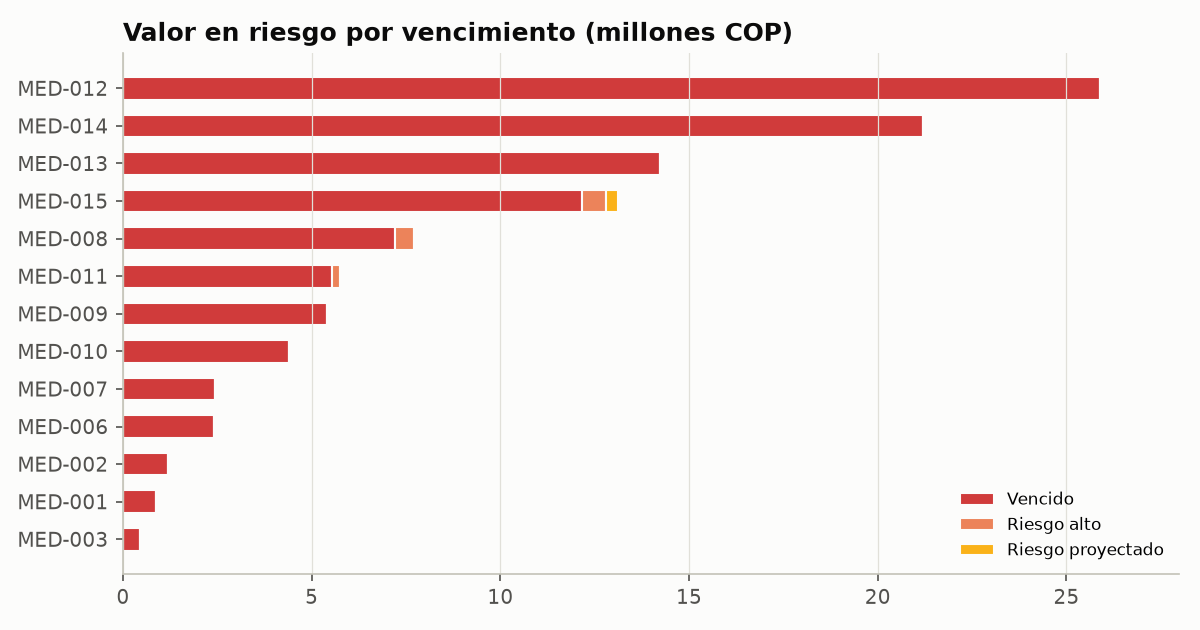

In [11]:
Image(figures.FIGURES / "06_riesgo_vencimiento.png")

## 5. Tabla consolidada de alertas

In [12]:
al = pd.read_csv(DATA_PROCESSED / "alertas.csv")
print(al.groupby(["tipo_alerta", "severidad"]).agg(alertas=("alerta_id", "size"), valor=("valor", "sum")))
al[["severidad", "tipo_alerta", "producto_id", "ubicacion_id", "lote_id", "mensaje"]].head(8)

                       alertas        valor
tipo_alerta severidad                      
SOBRESTOCK  MEDIA           75  193079010.0
VENCIMIENTO ALTA             3    1364850.0
            CRITICA         71  103394570.0
            MEDIA            1     327600.0


,severidad,tipo_alerta,producto_id,ubicacion_id,lote_id,mensaje
0,CRITICA,VENCIMIENTO,MED-014,LOC-004,LOT-00207,Lote vencido hace 241 días con 1365 u. Retirar...
1,CRITICA,VENCIMIENTO,MED-014,LOC-002,LOT-00200,Lote vencido hace 378 días con 1296 u. Retirar...
2,CRITICA,VENCIMIENTO,MED-012,LOC-005,LOT-00180,Lote vencido hace 233 días con 1445 u. Retirar...
3,CRITICA,VENCIMIENTO,MED-012,LOC-002,LOT-00169,Lote vencido hace 76 días con 1426 u. Retirar ...
4,CRITICA,VENCIMIENTO,MED-015,LOC-003,LOT-00219,Lote vencido hace 11 días con 1682 u. Retirar ...
5,CRITICA,VENCIMIENTO,MED-012,LOC-003,LOT-00172,Lote vencido hace 711 días con 1204 u. Retirar...
6,CRITICA,VENCIMIENTO,MED-012,LOC-004,LOT-00175,Lote vencido hace 951 días con 1114 u. Retirar...
7,CRITICA,VENCIMIENTO,MED-013,LOC-001,LOT-00181,Lote vencido hace 848 días con 1813 u. Retirar...


## Conclusiones de negocio

1. **Sobrestock generalizado:** ~$193 millones COP por encima del stock máximo recomendado. Pausar compras y redistribuir.
2. **Vencimientos:** 71 lotes ya vencidos (~$103 millones) deben darse de baja; 4 lotes adicionales tienen riesgo de vencer antes de consumirse.
3. **Proveedores:** la variabilidad del lead time explica la mayor parte del stock de seguridad; es la palanca de mejora más barata.
4. **Pronóstico → dinero:** un modelo más preciso reduce σ del error y, con él, el stock de seguridad requerido.

➡️ Estos resultados alimentan PostgreSQL (`sql/06_resultados_ml.sql`) y el tablero de Power BI (`docs/07_tablero_power_bi.md`).